In [38]:
import sys
sys.path.append('../python_packages_static/')
import pandas as pd
import pyemu
import flopy as fp
import matplotlib.pyplot as plt
import numpy as np
import os, glob, shutil
import geopandas as gp
import datetime as dt
import flopy as fp
from shapely.geometry import Point
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

In [39]:
run_ensemble=False

In [40]:
rundir = os.path.abspath(os.path.join("..", "pest", "master_run"))  # root directory for simulation
pstroot = "inversion_level_1" # PST file root for iES
outfolder = '{}/postproc/'.format(rundir)  # write out output files to this location
obs_data = '../processed_data/'
drop_pdc = False

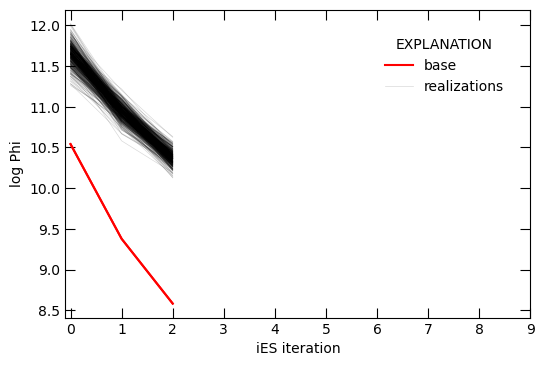

In [41]:
### visualise phi of the whole ensemble as it evolves over iES iterations
### the base run is highlighted in red, and the realizations are shown in black

phi = pd.read_csv(os.path.join(rundir,"{}.phi.actual.csv".format(pstroot)),index_col=0)
plt.figure(figsize=(6,4))
ax = phi['base'].apply(np.log10).plot(legend=False, lw=1.5, color='r', label='base')
phi.iloc[:,6:7].apply(np.log10).plot(legend=False,lw=0.5,color='k',alpha=0.15,label='realizations', ax = ax)
plt.legend(['base','realizations'])
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,alpha=0.15,color='k', ax = ax)
phi['base'].apply(np.log10).plot(legend=False, lw=1.5, color='r', ax=ax)
plt.ylabel('log Phi')
plt.xlabel('iES iteration')
plt.xticks(ticks=np.arange(10))
ax.axes.tick_params(length=7, direction='in', right=True, top=True)
plt.legend(['base','realizations'], title='EXPLANATION', frameon=False, bbox_to_anchor =(0.97, 0.95))

In [42]:
phi

,total_runs,mean,standard_deviation,min,max,0,1,2,3,4,...,490,491,492,493,494,495,496,497,498,base
iteration,,,,,,,,,,,,,,,,,,,,,
0,468,4.702390e+11,1.396070e+11,3.468400e+10,1.047280e+12,5.659070e+11,5.586130e+11,4.084110e+11,6.678810e+11,4.973810e+11,...,1.904170e+11,4.024120e+11,6.014140e+11,6.528830e+11,4.457030e+11,4.934940e+11,5.704700e+11,6.376500e+11,6.534600e+11,3.468400e+10
1,1302,8.855420e+10,1.954780e+10,2.383010e+09,1.647050e+11,9.559480e+10,1.080990e+11,5.648440e+10,7.465240e+10,1.136730e+11,...,6.572900e+10,7.910390e+10,7.549300e+10,8.792970e+10,8.456610e+10,7.454430e+10,1.081870e+11,9.141020e+10,8.435430e+10,2.383010e+09
2,2138,2.376680e+10,4.819020e+09,3.814970e+08,4.290060e+10,2.394840e+10,2.446080e+10,1.731540e+10,2.185990e+10,3.235160e+10,...,1.901030e+10,2.646620e+10,2.306310e+10,2.558850e+10,1.853610e+10,1.905560e+10,2.700020e+10,2.126480e+10,1.835600e+10,3.814970e+08


In [67]:
pst = pyemu.Pst('{0}/{1}.pst'.format(rundir, pstroot))

pst.nnz_obs

11024

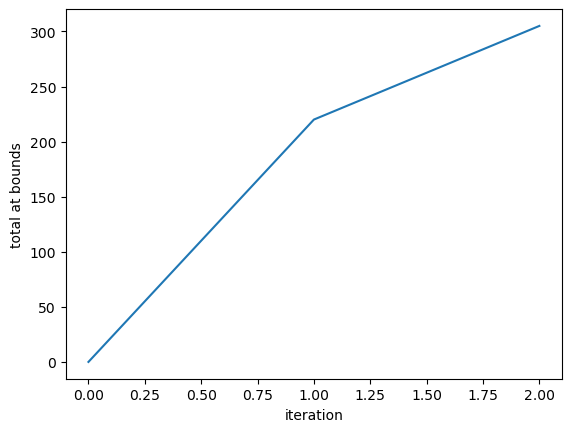

In [ ]:
# visualise the number of parameters at their bounds as it evolves over iES iterations

df = pst.bounds_report()
df_tot =  df[[i for i in df.columns if 'either' in i]].loc['total'].copy()
df_tot.index = [int(i.split('_')[-1]) for i in df_tot.index]
df_tot.plot()
plt.xlabel('iteration')
plt.ylabel('total at bounds')
plt.grid()
plt.grid()

In [45]:
best_iter = 1
# re-read in the PST file but now with the residuals corresponding with the best iteration
pst = pyemu.Pst('{0}/{1}.pst'.format(rundir, pstroot), 
                resfile=os.path.join(rundir,'{}.{}.base.rei'.format(pstroot,best_iter)))
obs=pst.observation_data

In [46]:
# plot 1to1 of the base ensemble run for the best iteration
figures_dir = Path("..") / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
save_path = figures_dir / f"{pstroot}.base.1to1_iter_{best_iter}.svg"
pst.plot(kind='1to1', filename=save_path)

In [47]:
# decide whether to drop the prior data conflict (PDC) values from the objective function 
# (i.e. zero weight them) for the post-processing of the iES results
if drop_pdc is True:
    # read in the PDC list of values
    pdc = pd.read_csv(os.path.join(rundir,'{}.pdc.csv'.format(pstroot)))
    pdc.name = pdc.name.apply(lambda x: x.lower())
    # zero weight all the PDC values
    obs.loc[pdc.name.values, 'weight'] = 0

11024


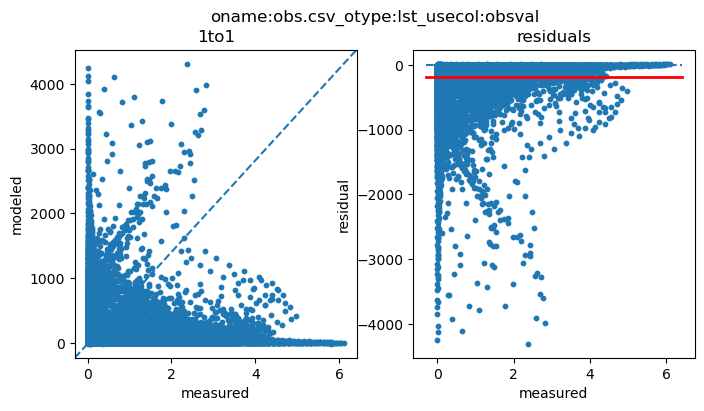

In [49]:
# plot residuals only for nonzero weight for the base realization which is read in automatically when pyemu reads in the pst control file

assert(np.unique(pst.res.index == obs.index))==np.array(True)
tmpres = pst.res.copy()
tmpres.weight = obs.weight
tmpres = tmpres.loc[pst.res.weight>0]
print(len(tmpres))
tmpres.head()

for cn,cg in tmpres.groupby('group'):
    fig, ax = plt.subplots(1,2, figsize=(8,4))
    ax[0].plot([0, 1], [0, 1],'--',transform=ax[0].transAxes)
    ax[0].scatter(cg.measured,cg.modelled, s=10)
    ax[0].set_xlabel('measured')
    ax[0].set_ylabel('modeled')
    ax[0].set_title('1to1')
    ax[1].scatter(cg.measured, cg.residual, s=10)
    xlim = ax[1].get_xlim()
    ax[1].plot(xlim, [0,0], '--')
    ax[1].plot(xlim, [cg.residual.mean(),cg.residual.mean()], 'r-', lw=2)
    ax[1].set_title('residuals')
    plt.suptitle(cn)
    ax[1].set_xlabel('measured')
    ax[1].set_ylabel('residual')

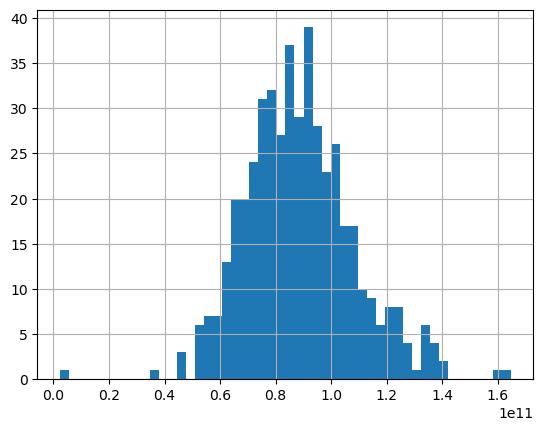

In [60]:
phivec = phi.loc[best_iter][5:].copy()
phivec.hist(bins=50)
phi_too_high = 0.8e11 

<>:30: DeprecationWarning: invalid escape sequence '\P'
<>:33: DeprecationWarning: invalid escape sequence '\P'
<>:37: DeprecationWarning: invalid escape sequence '\P'
<>:38: DeprecationWarning: invalid escape sequence '\P'
<>:30: DeprecationWarning: invalid escape sequence '\P'
<>:33: DeprecationWarning: invalid escape sequence '\P'
<>:37: DeprecationWarning: invalid escape sequence '\P'
<>:38: DeprecationWarning: invalid escape sequence '\P'
C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_35892\2224773435.py:30: DeprecationWarning: invalid escape sequence '\P'
C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_35892\2224773435.py:33: DeprecationWarning: invalid escape sequence '\P'
C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_35892\2224773435.py:37: DeprecationWarning: invalid escape sequence '\P'
C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_35892\2224773435.py:38: DeprecationWarning: invalid escape sequence '\P'


Number of reals before rejection sampling: 500
Number of reals after rejection sampling: 163


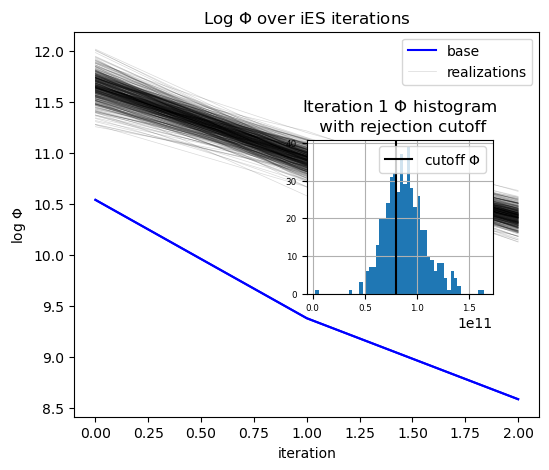

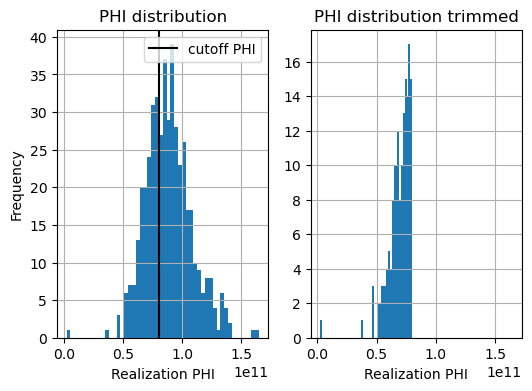

In [61]:
# plot phi evolution over iterations and the rejection sampling on the same plot

def add_subplot_axes(ax,rect,axisbg='w'):
    fig = plt.gcf()
    box = ax.get_position()
    width = box.width
    height = box.height
    inax_position  = ax.transAxes.transform(rect[0:2])
    transFigure = fig.transFigure.inverted()
    infig_position = transFigure.transform(inax_position)    
    x = infig_position[0]
    y = infig_position[1]
    width *= rect[2]
    height *= rect[3]  # <= Typo was here
    subax = fig.add_axes([x,y,width,height])
    x_labelsize = subax.get_xticklabels()[0].get_size()
    y_labelsize = subax.get_yticklabels()[0].get_size()
    x_labelsize *= rect[2]**0.5
    y_labelsize *= rect[3]**0.5
    subax.xaxis.set_tick_params(labelsize=x_labelsize)
    subax.yaxis.set_tick_params(labelsize=y_labelsize)
    return subax

fig = plt.figure(figsize=(6,5))
ax = phi['base'].apply(np.log10).plot(legend=False, lw=1.5, color='b', label='base')
phi.iloc[:,6:7].apply(np.log10).plot(legend=False,lw=0.5,color='k',alpha=0.15,label='realizations', ax = ax)
plt.legend(['base','realizations'])
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,alpha=0.15,color='k', ax = ax)
phi['base'].apply(np.log10).plot(legend=False, lw=1.5, color='b', ax=ax)
plt.ylabel('log $\Phi$')

ax1 = add_subplot_axes(ax, [0.5,.32,.4,0.4])
ax1.axvline(phi_too_high, color='k', label='cutoff $\Phi$')
ax1.legend()
phivec = phi.loc[best_iter][5:].copy()
phivec.hist(bins=50, ax=ax1)
ax.set_title('Log $\Phi$ over iES iterations')
ax1.set_title('Iteration {} $\Phi$ histogram\n with rejection cutoff'.format(best_iter)) 

plt.savefig('../figures/phi_and_rejection.svg')

phivec = phi.loc[best_iter][5:].copy()
fig, ax = plt.subplots(1,2, figsize=(6,4))
phivec.hist(bins=50, ax=ax[0])
ax[0].axvline(phi_too_high, color='k', label='cutoff PHI')
ax[0].legend()
ax[0].set_ylabel('Frequency')
print('Number of reals before rejection sampling: {}'.format(len(phivec)))
phivec = phivec[phivec<phi_too_high]
print('Number of reals after rejection sampling: {}'.format(len(phivec)))
phivec.hist(bins=50, ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
ax[0].set_xlabel('Realization PHI')
ax[1].set_xlabel('Realization PHI')
ax[0].set_title('PHI distribution')
ax[1].set_title('PHI distribution trimmed')

handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles, labels, loc='best')


plt.savefig('../figures/rejectionsampling.svg')

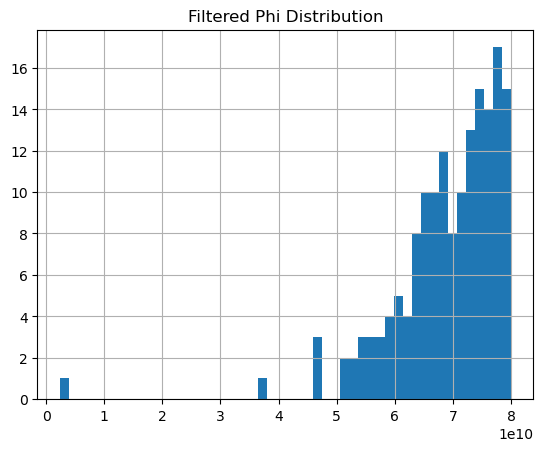

C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_35892\1589649132.py:18: DtypeWarning: Columns (0: oname:obs.csv_otype:lst_usecol:obsval_obsnme:h_p0_cp0) have mixed types. Specify dtype option on import or set low_memory=False.


[<Figure size 800x1050 with 0 Axes>, <Figure size 800x1050 with 8 Axes>]

<Figure size 800x1050 with 0 Axes>

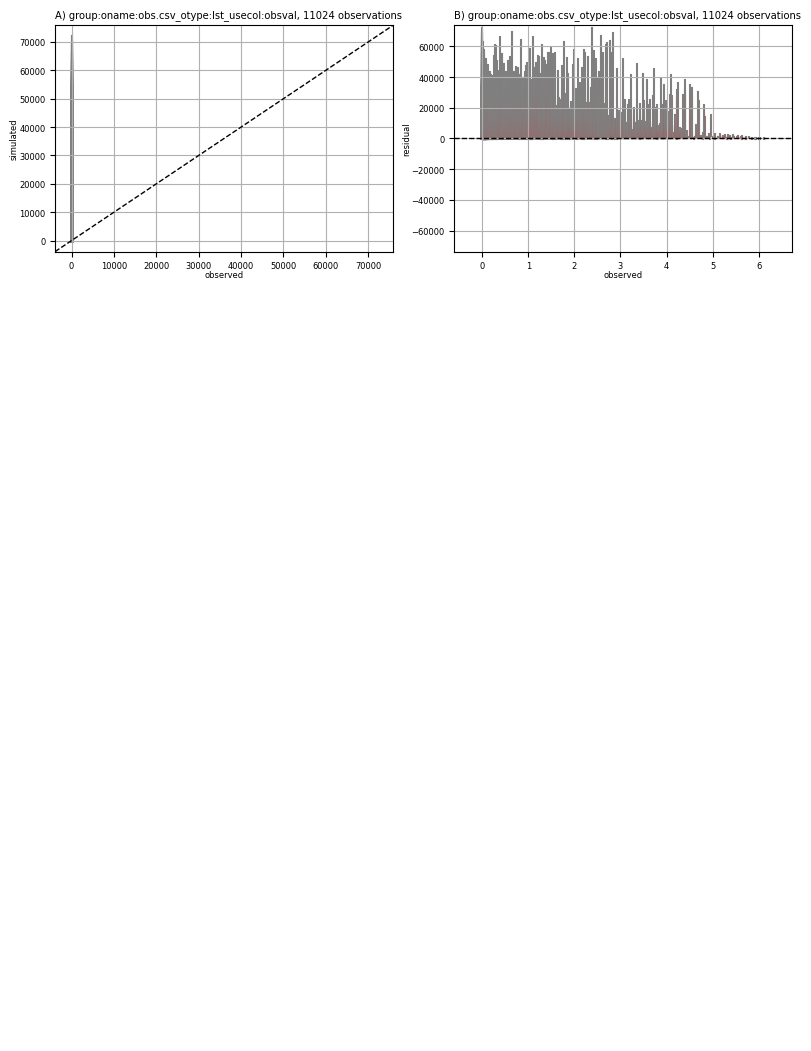

In [ ]:
# write a vector that keeps track of the ensemble members that made it through rejection sampling
reals_to_keep = phivec.index.values

# truncate the ensemble to only reals_to_keep (based on phi)
ens = pd.read_csv(os.path.join(rundir,'{}.0.obs.csv'.format(pstroot)), index_col=0)

# convert the index to string so that it can be used to index the ensemble dataframe
ens.index = ens.index.astype(str)

# filter the ensemble to only keep the realizations that passed the rejection sampling
ens = ens[ens.index.isin(reals_to_keep)]

# set percent_discrepancy to absolute value because we don't care about the sign
ens["perc_disc"] = np.abs(ens["perc_disc"])

# further truncate to eliminate bad mass balance runs 
ens = ens.loc[ens.perc_disc<0.01]

ens

ens.perc_disc.hist(bins=50)
plt.title('Ensemble mass balance percent discrepancy histogram')
plt.ylabel('count')
plt.xlabel('percent discrepancy')
plt.show()

C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_35892\2087474103.py:10: DtypeWarning: Columns (0: oname:obs.csv_otype:lst_usecol:obsval_obsnme:h_p0_cp0) have mixed types. Specify dtype option on import or set low_memory=False.


ValueError: Axis limits cannot be NaN or Inf

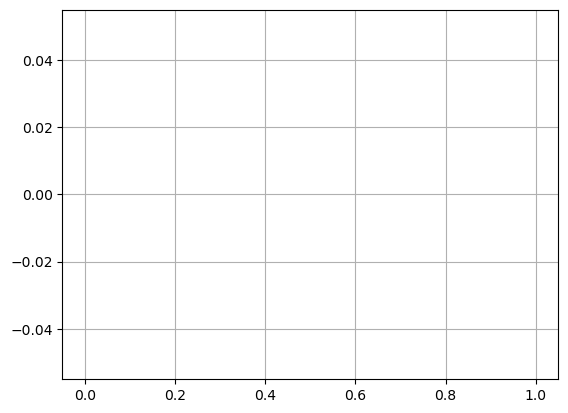

<Figure size 800x1050 with 0 Axes>

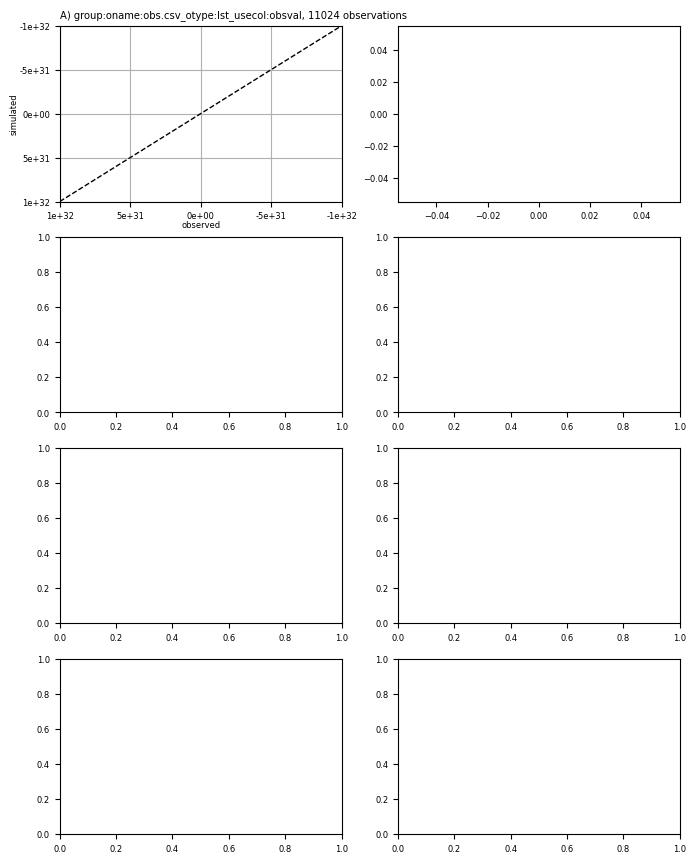

In [56]:
# get rid of zero-weighted values dropped in the PDC
ens = ens[tmpres.index]

# reset keepreals based now both on phi and mass balance
reals_to_keep = ens.index.values

phivec = phivec.loc[reals_to_keep]
phivec.hist(bins=50)

base_ens = pd.read_csv(os.path.join(rundir,'{}.0.obs.csv'.format(pstroot)), index_col=0)
base_ens = base_ens.loc[reals_to_keep]
base_ens = base_ens[tmpres.index]
pyemu.plot_utils.ensemble_res_1to1(ens, pst, base_ensemble=base_ens)

In [57]:
pdc = pd.read_csv(os.path.join(rundir,'{}.pdc.csv'.format(pstroot)))
pdc.name = pdc.name.apply(lambda x: x.lower())
pdc.set_index('name', inplace=True, drop=True)
pdc

drop_pdc = [i for i in pdc.index if not i.startswith('q_')] # make sure we still plot even if in PDC
ens = ens[[i for i in ens.columns if i not in drop_pdc]]
base_ens = base_ens[[i for i in ens.columns if i not in drop_pdc]]
tmpres = tmpres.loc[[i for i in ens.columns if i not in drop_pdc]]

obs_ens = pd.read_csv(os.path.join(rundir,'{}.obs+noise.csv'.format(pstroot)), index_col=0)
obs_ens = obs_ens.loc[reals_to_keep]
obs_ens

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Python\\Personal\\kfm-ms\\codes\\pest\\master_run\\inversion_level_1.pdc.csv'

In [ ]:
plot_pdf = False

if plot_pdf==True:
    with PdfPages('../figures/{}_trimmed_pdc_obs_hist_plots.pdf'.format(pstroot)) as outpdf:
        for cob in tmpres.index.values:
            plt.figure()

            obs_ens[cob].hist(bins=50, color='orange', edgecolor='none', alpha=.7,label='observed')
            ens[cob].hist(bins=50, edgecolor='none', label='modelled')
            plt.axvline(obs_ens[cob].mean(), mfc='k', alpha=.5,label='obs mean')
            plt.axvline(obs_ens[cob].mean()+obs_ens[cob].std(), mfc='k', ls=':', alpha=.5, label='obs + 1$\sigma$')
            plt.axvline(obs_ens[cob].mean()-obs_ens[cob].std(), mfc='k', ls=':', alpha=.5, label='obs - 1$\sigma$')


            plt.title(cob)
            plt.legend()
            outpdf.savefig()
            plt.close('all')


In [ ]:
# save out the paremeter ensemble to supply to the model
par_ens = pd.read_csv(os.path.join(rundir,'{0}.{1}.par.csv'.format(pstroot, best_iter)), index_col=0)
par_ens.index = [str(i) for i in par_ens.index]
par_ens = par_ens.loc[reals_to_keep]
par_ens.to_csv('../run_data/modpath_par_ens.csv')

# save out the base realization as a representative single model serving as an optimal set of parameters and outputs

# select the base realization from the parameter ensemble corresponding to the best iteration
base_pars = par_ens.loc['base']
pst = pyemu.Pst('{0}/{1}.pst'.format(rundir, pstroot), 
                resfile=os.path.join(rundir,'{}.{}.base.rei'.format(pstroot,best_iter)))
pst.parameter_data.loc[:,'parval1'] = base_pars

# make a copy of run_data to contain the representative ensemble run and call it representative_optimal_ensemble_run
if os.path.exists('../representative_optimal_ensemble_run'):
    shutil.rmtree('../representative_optimal_ensemble_run')
shutil.copytree('../run_data','../representative_optimal_ensemble_run')

# write out the pst control file with the optimal base set of parameters
pst.control_data.noptmax=0
pst.write('../representative_optimal_ensemble_run/optimal_base_run.pst')

pyemu.os_utils.run('pestpp-ies optimal_base_run.pst',
                  cwd = '../representative_optimal_ensemble_run',
                  verbose=True)